
# Day 35 — Training Loops & Optimizers in Deep Learning

## Topics Covered
- Training Loops
- SGD
- SGD with Momentum
- Nesterov Accelerated Gradient (NAG)
- Adagrad
- RMSProp
- Adam
- NAdam
- Practical Hands-on with PyTorch



# Why Optimizers Matter

Neural Networks learn by updating weights repeatedly.

But an important question is:

> **How should weights be updated?**

That decision is handled by the **optimizer**.

Different optimizers use different strategies to:
- move faster
- avoid oscillation
- handle noisy gradients
- adapt learning rates
- improve convergence

---

# Core Training Pipeline

```text
Forward Pass
    ↓
Loss Calculation
    ↓
Backward Pass (Backpropagation)
    ↓
Optimizer Updates Weights
    ↓
Repeat
```

---

# Simple Real-World Analogy

Imagine you are blindfolded on a mountain.

Your goal:
Reach the lowest point.

Optimizers are different walking strategies.

Some:
- walk carefully
- remember past direction
- predict future turns
- adapt step sizes dynamically



# Training Loop in PyTorch

## Basic Structure

```python
for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train)

    # Compute loss
    loss = criterion(outputs, y_train)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()
```

---

# Key Components

| Component | Purpose |
|---|---|
| Forward Pass | Generate predictions |
| Loss Function | Measure error |
| Backpropagation | Compute gradients |
| Optimizer | Update weights |
| Epoch | One full pass through dataset |

---

# Important Insight

```text
Backpropagation computes gradients.
Optimizer decides how to use them.
```



# 1. Stochastic Gradient Descent (SGD)

## Logical Understanding

SGD only looks at the current slope.

It asks:

```text
Which direction reduces loss right now?
```

Then it takes a small step.

---

## Real Behavior

- Very reactive
- No memory
- Can zig-zag heavily
- Slower convergence

---

## Mental Model

```text
A beginner hiker taking tiny careful steps downhill.
```

---

# 2. SGD with Momentum

## Logical Understanding

Momentum remembers previous movement direction.

Instead of reacting only to current gradient:

```text
Use past velocity to continue moving smoothly.
```

---

## Why Better

- Faster movement
- Less oscillation
- Smoother convergence

---

## Mental Model

```text
A heavy ball rolling downhill.
```

---

# 3. Nesterov Accelerated Gradient (NAG)

## Logical Understanding

Momentum can overshoot.

NAG asks:

```text
Where will momentum take me next?
```

Then computes gradient there.

---

## Why Useful

- Predictive correction
- Smarter movement
- Better stability

---

## Mental Model

```text
A smart driver slowing before a curve.
```

---

# 4. Adagrad

## Logical Understanding

Different parameters learn at different speeds.

Adagrad:
- reduces learning for frequent features
- increases learning for rare features

---

## Best For

- NLP
- Sparse datasets
- Recommendation systems

---

## Limitation

Learning rate keeps shrinking forever.

---

## Mental Model

```text
A teacher giving extra attention to weaker students.
```

---

# 5. RMSProp

## Logical Understanding

Adagrad remembers all history forever.

RMSProp says:

```text
Focus more on recent gradients.
```

---

## Why Powerful

- Prevents learning from stopping
- Keeps updates active
- Handles changing patterns better

---

## Common Uses

- RNNs
- Time Series
- Speech Models

---

## Mental Model

```text
A trader focusing on recent market trends.
```

---

# 6. Adam

## Logical Understanding

Adam combines:
- Momentum
- RMSProp

It remembers direction AND adapts learning rate.

---

## Why Popular

- Fast convergence
- Stable training
- Works well almost everywhere
- Requires less tuning

---

## Mental Model

```text
A smart GPS system adjusting both speed and direction.
```

---

# 7. NAdam

## Logical Understanding

NAdam = Adam + Nesterov look-ahead.

It predicts future movement before updating.

---

## Why Useful

- Sometimes smoother convergence
- Better stability
- Slightly better accuracy

---

## Mental Model

```text
A Formula-1 driver predicting the next curve.
```



# Hands-on Section

We will now:
1. Create synthetic data
2. Build a Neural Network
3. Train using different optimizers
4. Compare performance

---

# Install PyTorch (If Needed)

```python
!pip install torch torchvision matplotlib scikit-learn
```


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [2]:

# Create synthetic dataset

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

print(X_train.shape)
print(y_train.shape)


torch.Size([800, 2])
torch.Size([800, 1])


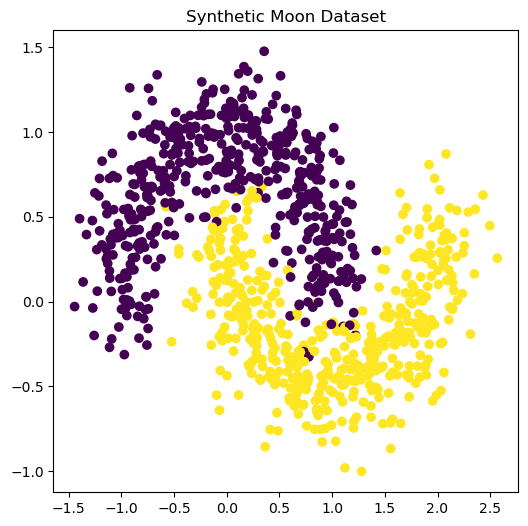

In [3]:

# Visualize dataset

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Synthetic Moon Dataset")
plt.show()


In [4]:

# Simple Neural Network

class SimpleNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),

            nn.Linear(16, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


In [5]:

# Generic Training Function

def train_model(optimizer_name='SGD', lr=0.01):

    model = SimpleNN()

    criterion = nn.BCELoss()

    # Select optimizer

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)

    elif optimizer_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif optimizer_name == 'NAG':
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            nesterov=True
        )

    elif optimizer_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=lr)

    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)

    elif optimizer_name == 'NAdam':
        optimizer = optim.NAdam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(200):

        # Forward pass
        outputs = model(X_train)

        # Compute loss
        loss = criterion(outputs, y_train)

        # Clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Weight update
        optimizer.step()

        losses.append(loss.item())

    return losses


In [6]:

# Compare Optimizers

optimizers_list = [
    'SGD',
    'Momentum',
    'NAG',
    'Adagrad',
    'RMSProp',
    'Adam',
    'NAdam'
]

results = {}

for opt_name in optimizers_list:

    print(f"Training with {opt_name}")

    losses = train_model(opt_name)

    results[opt_name] = losses


Training with SGD
Training with Momentum
Training with NAG
Training with Adagrad
Training with RMSProp
Training with Adam
Training with NAdam


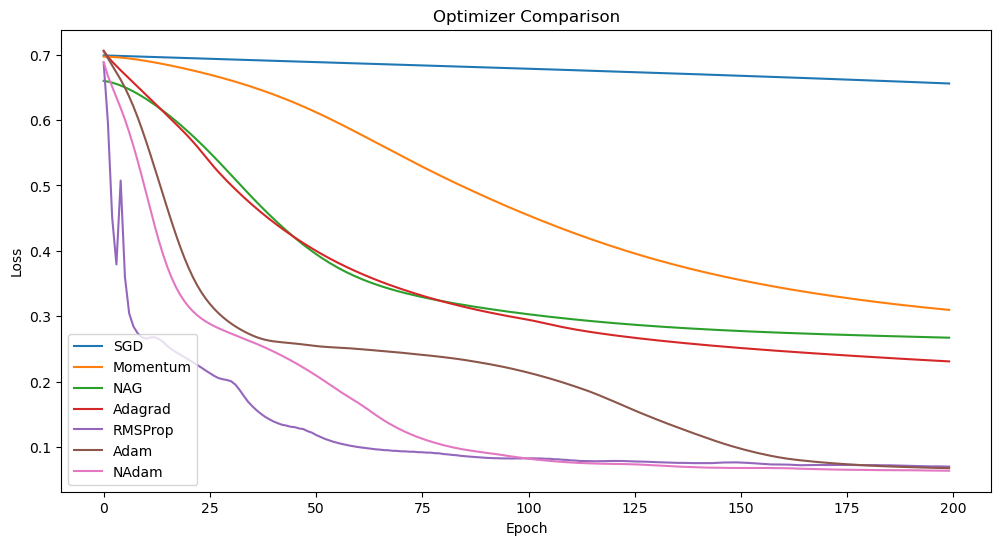

In [7]:

# Plot Loss Curves

plt.figure(figsize=(12,6))

for opt_name, losses in results.items():
    plt.plot(losses, label=opt_name)

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()



# Observations from Results

## SGD
- Slower convergence
- More oscillation

## Momentum
- Smoother than SGD
- Faster movement

## NAG
- More stable than Momentum
- Better directional correction

## Adagrad
- Learns quickly initially
- Slows down later

## RMSProp
- Stable learning
- Good for non-stationary problems

## Adam
- Fastest practical convergence
- Most stable overall

## NAdam
- Similar to Adam
- Sometimes slightly smoother



# Real Industry Usage

| Domain | Common Optimizer |
|---|---|
| Computer Vision | SGD + Momentum |
| NLP | Adam / AdamW |
| Transformers | AdamW |
| RNNs | RMSProp |
| Recommendation Systems | Adagrad |
| LLM Training | AdamW |

---

# Important Interview Questions

## Why does Adam work so well?

Because it:
- remembers direction
- adapts learning rate
- handles noisy gradients
- converges quickly

---

## Why is SGD still used?

Because:
- better generalization sometimes
- simpler behavior
- works extremely well in large-scale vision tasks



# Mini Project Challenge

Try the following:

## Task 1
Increase:
```python
noise=0.4
```

Observe optimizer behavior.

---

## Task 2
Change learning rates:
```python
lr = 0.1
lr = 0.001
```

Observe stability.

---

## Task 3
Add more hidden layers.

---

## Task 4
Train on real datasets:
- MNIST
- CIFAR-10
- FashionMNIST

---

# Final Takeaway

```text
Training loop = learning process
Optimizer = learning strategy
```

A powerful optimizer can:
- speed up training
- improve convergence
- stabilize deep networks
- improve final accuracy
